In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) # silences future development warninigs

import earthaccess
import folium
import geopandas as gpd
import numpy as np
np.seterr(divide='ignore', invalid='ignore') # silence maths warnings (0/0 or X/0) globally
import pandas as pd
from pathlib import Path
import rasterio as rio
import rasterio.merge
from rasterio import features
from rasterio.merge import merge
from rasterio.windows import from_bounds
from rasterstats import zonal_stats
import rioxarray
import shapely
from shapely.geometry import shape
import xarray as xr
from xrspatial import hillshade
import matplotlib.pyplot as plt


def get_bands_by_satellite():
    records = []

    # Map colors to band numbers based on the Satellite ID prefix
    # LT04/05 = Landsat 4/5 TM; LE07 = Landsat 7 ETM+; LC08/09 = Landsat 8/9 OLI
    band_config = {
    "LT05":{"B1":"blue", "B2":"green", "B3":"red", "B4":"nir", "B5":"swir1", "B7":"swir2"},
    "LE07":{"B1":"blue", "B2":"green", "B3":"red", "B4":"nir", "B5":"swir1", "B7":"swir2"},
    "LC08":{"B1":"coast/aero", "B2":"blue", "B3":"green", "B4":"red", "B5":"nir", "B6":"swir1", "B7":"swir2"},
    "LC09":{"B1":"coast/aero", "B2":"blue", "B3":"green", "B4":"red", "B5":"nir", "B6":"swir1", "B7":"swir2"}
}
    for folder in PATHS["landsat_images"].iterdir():
        if folder.is_dir():
            for file in folder.glob("*_SR_B*.TIF"):
                parts = file.name.split("_")
                sat_id = parts[0][:4]
                band_id = parts[-1].replace(".TIF", "")

                sat_map = band_config.get(sat_id, {})
                colour = sat_map.get(band_id)
                
                if colour in ALL_COLOURS:
                    records.append({
                        "satellite": sat_id,
                        "path_row": parts[2],
                        "year": parts[3][:4],
                        "band": band_id,
                        "colour": band_config[sat_id][band_id],
                        "filename": file.name,
                        "path": str(file)
                    })
    return pd.DataFrame(records)


def create_mosaic(file_list, out_path, dtype=None, nodata_val=None):
    # a. Open first file to get 'Master' CRS
    with rio.open(file_list[0]) as src:
        target_crs = src.crs
        out_meta = src.profile.copy()
        if nodata_val is None:
            nodata_val = src.nodata
        
    # b. Check CRS of each file. Reproject ones that don't match, then pass each file to to_merge 
    to_merge = []
    for f in file_list:
        with rio.open(f) as src:
            if src.crs != target_crs:
                print(f"Fixing CRS for: {Path(f).name}")
                # Replace the path with the reprojected object
                to_merge.append(fix_projection(f, target_crs))
            else:
                # Keep it as a path - merge handles paths efficiently
                to_merge.append(f)
               
    # c. merge files
    mosaic, out_trans = merge(to_merge, nodata=0)

    for s in to_merge:
        if hasattr(s, 'close'):
            s.close()
   
    # d. Update mosaic metadata and save
    bands, height, width = mosaic.shape
    out_meta.update({
        "height": height, 
        "width": width, 
        "transform": out_trans, 
        "nodata": 0,
        "dtype": dtype or out_meta['dtype']
    })

    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rio.open(out_path, "w", **out_meta) as dest:
        dest.write(mosaic)
    print(f"     Mosaic saved: {out_path.name}")
    return out_path    


    

def build_dataset(file_map):
    yearly_ds = []
    for year, bands in file_map.items():
        band_list = []
        for name, path in bands.items():
            # Open with chunks for Dask (lazy loading)
            da = rioxarray.open_rasterio(path, chunks={'x': 2048, 'y': 2048})
            da = da.squeeze().drop_vars('band').rename(name)
            band_list.append(da)
        
        # Merge bands and assign the year coordinate
        ds_year = xr.merge(band_list).assign_coords(year=year)
        yearly_ds.append(ds_year)

    return xr.concat(yearly_ds, dim='year')



# --- 1. User Inputs ---
base = Path("C:/RS_GIS/EGM722/Assignment/Grand_Canyon/USGS_data/Unzipped") # insert path of base directory into brackets, eg. Path(<base_folder_location>)
roi = Path("C:/RS_GIS/EGM722/Assignment/Grand_Canyon/USGS_data/Unzipped/Boundary Files/national_park_boundary.shp")
external_river_path = Path()

#select desired display and analysis: 0 = not wanted, 1 = wanted.
DISPLAY_OPTIONS = {
    "true_colour": 1,
    "false_colour": 0
}
ANALYSIS_OPTIONS = {
    "ndvi": 1,
    "ndwi": 0,
    "ndsi": 0
}
print("1. User Inputs and selections accepted")



# --- 2. Create folder structure ---
PATHS = {
    "landsat_images" : base / "Landsat_Images",
    "ndi": base / "NDI Images",
    "mosaics": base / "Mosaics",
    "boundaries": base / "Boundary Files",
    "earthaccess": base / "EarthAccess",
    "results": base / "Results"
}
for p in PATHS.values(): p.mkdir(parents=True, exist_ok=True)
print("2. Directories checked/created")



# --- 3. Determine colour bands requried for selected disaply / analysis 
INDEX_TO_BANDS = {
    "true_colour" : ["red", "green","blue"],
    "false_colour" : ["nir","red","green"],
    "ndvi": ["red", "nir"],
    "ndwi": ["nir","green"],
    "ndsi": ["swir1","green"]
}



DISPLAY_TASKS = [k for k, v in DISPLAY_OPTIONS.items() if v == 1] # 1. Extract active tasks (where value is 1)
ANALYSIS_TASKS = [k for k, v in ANALYSIS_OPTIONS.items() if v == 1]
DISPLAY_COLOURS = {band for task in DISPLAY_TASKS for band in INDEX_TO_BANDS[task]} # 2. Extract unique bands for those tasks using a Set comprehension
ANALYSIS_COLOURS = {band for task in ANALYSIS_TASKS for band in INDEX_TO_BANDS[task]}
ALL_COLOURS = list(DISPLAY_COLOURS | ANALYSIS_COLOURS) # 3. Combine everything for the master download/mosaic list # Using | on sets is the cleanest way to merge them
print("3. Band identification and mapping completed")




# --- 4. Build DataFrame of rasters needed for mosaicking ---
df = get_bands_by_satellite()
if df.empty:
    print("4. !!!WARNING: No matching bands found. Check folder paths or band_config.!!!")
    sys.exit()
df.to_csv(PATHS["landsat_images"] / "bands_dataframe.csv", index=False)
print(F"4. Image dataset created: {len(df)} files included")



# --- 5. Mosaick Rasters ---
file_map={}
print("5. Mosaicking started...")
for (year, colour), group in df.groupby(['year', 'colour']):
    file_list = group['path'].tolist()     # Get the file paths from the DataFrame   
    dst_path = PATHS["mosaics"] / f"{year}_{colour}_mosaic.tif"
    mosaic_path = create_mosaic(file_list, dst_path, nodata_val=0)     # Run the mosaic function and output the file path (for subsequent processing) 
    
    # Build a map of file paths to build the xarray need for processing  
    if year not in file_map:
        file_map[year] = {}
    file_map[year][colour.lower()] = mosaic_path
print("     All rasters mosaicked")



# --- 6. Build Dataset of Mosaikced Images  ---
ds = build_dataset(file_map) #Creates Dataset and fills with landast images
print("6. Dataset of mosaicked band data completed")



# --- 7. Create Composite Images - potnetial move to 'displying' scripting---
print("7. Creating composite images")
for year in df["year"].unique():
    for disp_tsk in DISPLAY_TASKS:
        img = ds[INDEX_TO_BANDS[disp_tsk]].sel(year=year).to_array(dim='band')
        img_dest = PATHS["results"] / f"{year}_{disp_tsk}_composite_full_res.tif"
        img.rio.to_raster(img_dest)
        print(f"     Composite saved: {year} {disp_tsk}")



# --- 8. NDVI and NDWI Analysis ---
roi_gdf = gpd.read_file(roi)
roi_gdf = roi_gdf.to_crs(ds.rio.crs) # convert ROI (park boundary) to same CRS as dataset
ds_clipped = ds.rio.clip(roi_gdf.geometry, ds.rio.crs, drop=True) # Clip the entire Dataset and trims empty outersapce (drop=TRUE)
ds_clean = ds_clipped.where(ds_clipped > 0) # ignore zeros that can reult in calualtion erres (e.g. /0)
for task in ANALYSIS_TASKS:
    b1_name = INDEX_TO_BANDS[task][0]
    b2_name = INDEX_TO_BANDS[task][1]
    b1 = ds_clean[b1_name].astype(float) # Convert to float (from landsat uint16) to prevent wrap around 
    b2 = ds_clean[b2_name].astype(float) # Convert to float (from landsat uint16) to prevent wrap around 
    ds_clipped[task] = (b2-b1)/(b2+b1)
print("8. Normalized Difference Index Analysis Completed")


# # Create a mask for the river
# river_mask = ds_clipped['ndwi'].isel(year=0) > 0.1
# # Apply this to NDVI to analyze only 'Land' pixels
# ndvi_land_only = ds_clipped['ndvi'].where(~river_mask)



# --- 9. Acquire DEMs for mEarth Access---
roi_4326 = roi_gdf.to_crs(epsg = 4326).union_all() #projection EPSG 4326 needed for earthacess
search_area = roi_4326.minimum_rotated_rectangle
search_area = shapely.geometry.polygon.orient(search_area, sign=1)
#getting dem data from earthaccess
print("9. EarthAccess data acquistion started...")
earthaccess.login(strategy='netrc')
earthaccess_files = earthaccess.search_data(
    short_name = 'ASTGTM',
    polygon = search_area.exterior.coords
)
if len(earthaccess_files) == 0:
    print("  No Data Found in Earth Access")
    #code here to stop whole program?
    
earthaccess_dest = PATHS["earthaccess"]
downloaded_files = earthaccess.download(earthaccess_files, earthaccess_dest)


# --- 10. mosaicking the DEMs ---

print("10. Mosaicking DEMs...")
dem_files = [fn for fn in downloaded_files if 'dem.tif' in fn.name]
dem_mosaic_path = PATHS["mosaics"] / "DEM_mosaic.TIF"
create_mosaic(dem_files, dem_mosaic_path, dtype='float32')
print("     DEMs mosaicked")


print("11. Vectorising DEM...")
#clipping large dem mosaic to park area polygon 
dem_master = rioxarray.open_rasterio(dem_mosaic_path).squeeze()
roi_dem = roi_gdf.to_crs(dem_master.rio.crs)
dem_clipped = dem_master.rio.clip(roi_dem.geometry, drop=True)

#vectorising the raster into height steps
step = 250
dem_segmented = (dem_clipped.values // step).astype("int32")
mask = ~np.isnan(dem_segmented)
shapes = features.shapes(dem_segmented, mask=mask,transform=dem_clipped.rio.transform())
polygons = []
for i, (geom, value) in enumerate(shapes):
    zone_label = int(value*step)
    polygons.append({
        'poly_id':i,
        'elevation_zone': zone_label,
        'geometry':shape(geom)
    })
segments_gdf = gpd.GeoDataFrame(polygons, crs=dem_clipped.rio.crs)
print("      Vectorising completed")


# --- 12. Spatial Analysis started
# reprojecting height polygons to landsat crs
segments_gdf = segments_gdf.to_crs(ds_clipped.rio.crs)
print("12. Calculating Zonal Statistics")

# all_results = []

# for yr in ds_clipped.year.values:
#     print(f"      Calculating {yr} stats...")
#     # Load the full year into memory once to make it fast
#     ndvi_yr = ds_clipped.ndvi.sel(year=yr).compute()

#     for i, row in segments_gdf.iterrows():
#         try:
#             # Use Xarray's own clipping tool instead of rasterstats
#             # This 'crops' the data to the specific polygon
#             clipped = ndvi_yr.rio.clip([row.geometry], drop=True)
            
#             # Calculate mean and std on the clipped piece
#             # .item() turns the single-value array into a standard number
#             m = clipped.mean(skipna=True).item()
#             s = clipped.std(skipna=True).item()

#             if not np.isnan(m):
#                 all_results.append({
#                     'year': yr,
#                     'height': row['elevation_zone'],
#                     'mean': m,
#                     'std': s  
#                 })
#         except (ValueError, Exception):
#             # If a polygon is completely outside the data, just skip it
#             continue

# veg_stats_df = pd.DataFrame(all_results)


# all_results = []
# for yr in ds_clipped.year.values:
#     print(f"      Calculating {yr} stats...")
#     ndvi_yr = ds_clipped.ndvi.sel(year=yr)
    
#     # We must compute the values once here so the loop is fast
#     ndvi_values = ndvi_yr.values 
#     affine = ds_clipped.rio.transform()

#     for i, poly in enumerate(segments_gdf.geometry):
#         try:
#             # We run the stats one polygon at a time
#             # We add all_touched=True to give it the best chance to find data
#             s = zonal_stats(
#                 poly, 
#                 ndvi_values, 
#                 affine=affine, 
#                 stats=['mean', 'std'], 
#                 nodata=np.nan,
#                 all_touched=True 
#             )[0] # zonal_stats returns a list, so we take the first item

#             # Only record if we actually found data (mean is not None)
#             if s['mean'] is not None:
#                 all_results.append({
#                     'year': yr,
#                     'height': segments_gdf.iloc[i]['elevation_zone'],
#                     'mean': s['mean'],
#                     'std': s['std']  
#                 })
        
#         except ValueError:
#             # This catches the 'width/height > 0' error and just skips that polygon
#             # It means this height zone doesn't exist in this specific year's data
#             continue
# veg_stats_df = pd.DataFrame(all_results)
# output_file = PATHS["results"] / "final_stats.csv"
# veg_stats_df.to_csv(output_file, index=False) 


# print("      All zonal statistics calculated.")




segments_gdf = segments_gdf.to_crs(ds_clipped.rio.crs)

all_results = []
for yr in ds_clipped.year.values:
    print(f"      Calculating {yr} stats...")
    ndvi_yr = ds_clipped.ndvi.sel(year = yr)
    stats = zonal_stats(
        segments_gdf,
        ndvi_yr.values,
        affine=ds_clipped.rio.transform(), 
        stats=['mean', 'std'],
        nodata=np.nan,
        all_touched=True 
    )

    for i,s in enumerate(stats):
        all_results.append({
            'year' : yr,
            'height': segments_gdf.iloc[i]['elevation_zone'],
            'mean':s['mean'],
            'std':s['std']  
        })

veg_stats_df = pd.DataFrame(all_results)
output_file = PATHS["results"] / "final_stats.csv"
veg_stats_df.to_csv(output_file, index=False) 

print("      All zonal statistics calculated.")

print("--- Code completed ---")

1. User Inputs and selections accepted
2. Directories checked/created
3. Band identification and mapping completed
4. Image dataset created: 8 files included
5. Mosaicking started...
     Mosaic saved: 2025_blue_mosaic.tif
     Mosaic saved: 2025_green_mosaic.tif
     Mosaic saved: 2025_nir_mosaic.tif
     Mosaic saved: 2025_red_mosaic.tif
     All rasters mosaicked
6. Dataset of mosaicked band data completed
7. Creating composite images
     Composite saved: 2025 true_colour
8. Normalized Difference Index Analysis Completed
9. EarthAccess data acquistion started...


QUEUEING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/16 [00:00<?, ?it/s]

10. Mosaicking DEMs...
     Mosaic saved: DEM_mosaic.TIF
     DEMs mosaicked
11. Vectorising DEM...
      Vectorising completed
12. Calculating Zonal Statistics
      Calculating 2025 stats...
      All zonal statistics calculated.
      Calculating 2025 stats...
--- Code completed ---


In [2]:
veg_stats_df

,year,height,mean,std
0,2025,1500,0.125677,0.004317
1,2025,1750,0.116426,0.007936
2,2025,1750,0.103471,0.003145
3,2025,1750,0.105486,0.005613
4,2025,1750,0.120375,0.007869
...,...,...,...,...
9582,2025,1000,0.101624,0.002781
9583,2025,1000,0.097362,0.004956
9584,2025,0,0.092434,0.025880
9585,2025,1250,0.089008,0.010824


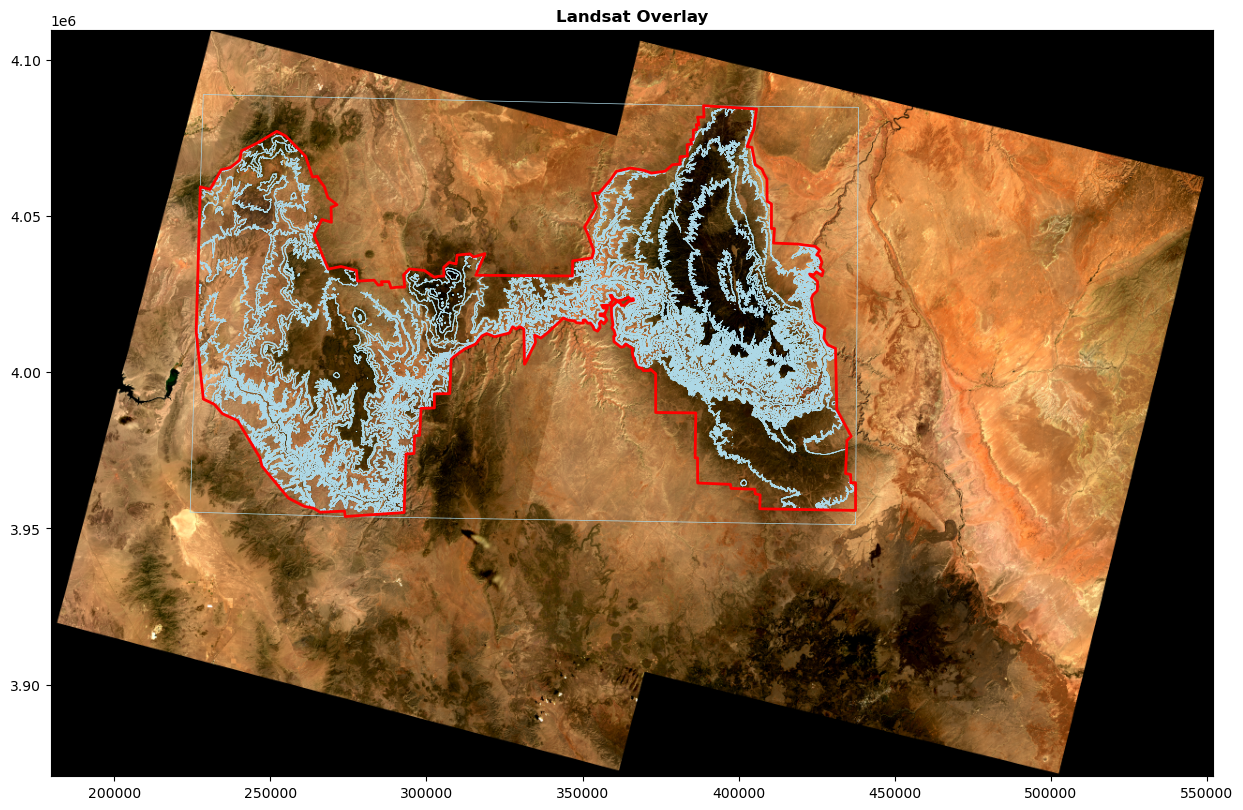

In [4]:
import rasterio
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt

landsat_image = PATHS['results']/"2020_true_colour_composite.tif"
polygons = PATHS['results']/"final_vegetation_stats.csv"
# 1. Open the Landsat raster
with rasterio.open(landsat_image) as src:
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # 2. Display the raster (e.g., using the first three bands for RGB)
    # Use transform=src.transform to keep the plot in map coordinates
    show(src, ax=ax, title="Landsat Overlay")

    # 3. Load and reproject your polygon dataframe
    roi_4326 = roi_gdf.to_crs(epsg = 26912)
#    gdf = gpd.read_file(polygons)
#    gdf = gdf.to_crs(src.crs) # Vital for alignment

    # 4. Overlay the polygons
    segments_gdf.plot(ax=ax, facecolor ='none',edgecolor ='lightblue',linewidth=0.5)
    roi_4326.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

plt.show()

In [ ]:
# import numpy as np
# from rasterio.transform import from_bounds

# # 1. Grab raw data
# ndvi_raw = ds_clipped.ndvi.sel(year='2020').compute().values
# left, bottom, right, top = ds_clipped.rio.bounds()
# height, width = ndvi_raw.shape

# # 2. Manually reconstruct the transform from the bounds
# # This forces the orientation to be 'Standard'
# manual_transform = from_bounds(left, bottom, right, top, width, height)

# # 3. Test Polygon 500 (avoiding index 0 just in case)
# test_poly = segments_gdf.geometry.iloc[500]

# try:
#     s = zonal_stats(
#         test_poly, 
#         ndvi_raw, 
#         affine=manual_transform, 
#         stats=['mean', 'count'],
#         all_touched=True
#     )
#     print(f"Manual Transform Success: {s}")
# except Exception as e:
#     print(f"Manual Transform Failure: {e}")

In [ ]:
# import numpy as np
# from rasterio.transform import Affine

# # 1. Grab 2020 and force it to be a real numpy array in memory
# ndvi_2020 = ds_clipped.ndvi.sel(year='2020').compute().values

# # 2. Get the transform specifically from the rio accessor
# # This ensures it's a 'proper' Affine object
# affine_obj = ds_clipped.rio.transform()

# # 3. Test a single polygon again
# # We'll use a middle polygon (e.g., index 500) to avoid any edge issues
# test_poly = segments_gdf.geometry.iloc[500]

# try:
#     s = zonal_stats(
#         test_poly, 
#         ndvi_2020, 
#         affine=affine_obj, 
#         stats=['mean', 'count'],
#         nodata=np.nan,
#         all_touched=True
#     )
#     print(f"Success! Result: {s}")
# except Exception as e:
#     print(f"Still failing: {e}")


In [ ]:
# # 1. Grab the 2020 NDVI (which we know has data)
# ndvi_2020 = ds_clipped.ndvi.sel(year='2020').compute()

# # 2. Check the CRS and Bounds of both
# print(f"Data CRS: {ds_clipped.rio.crs}")
# print(f"Poly CRS: {segments_gdf.crs}")
# print(f"Data Bounds: {ds_clipped.rio.bounds()}")
# print(f"Poly Bounds: {segments_gdf.total_bounds}")

# # 3. Test a single polygon to see why it's 'None'
# test_poly = segments_gdf.geometry.iloc[0]
# s = zonal_stats(
#     test_poly, 
#     ndvi_2020.values, 
#     affine=ds_clipped.rio.transform(), 
#     stats=['mean', 'count'],
#     nodata=np.nan,
#     all_touched=True
# )
# print(f"Test Result: {s}")

In [ ]:
# # Check what the columns are actually named
# print(f"Columns found in dataframe: {veg_stats_df.columns.tolist()}")

# # Use the column name exactly as printed above (likely lowercase 'year')
# # This version also handles the describe() more cleanly
# quality_summary = veg_stats_df.groupby('year')['mean'].describe()
# print(quality_summary)

In [ ]:
# # Check basic statistics for each year
# quality_summary = veg_stats_df.groupby('year')['mean'].describe()
# print(quality_summary)

# # Check for 'Impossible' NDVI values
# outliers = veg_stats_df[(veg_stats_df['mean'] < -1) | (veg_stats_df['mean'] > 1)]
# print(f"Number of impossible NDVI values: {len(outliers)}")


In [ ]:
# # We compute these to make the loop fast
# ndvi_2010 = ds_clipped.ndvi.sel(year=2010).compute()
# ndvi_2020 = ds_clipped.ndvi.sel(year=2020).compute()

# for i, poly in enumerate(segments_gdf.geometry):
#     # Check 2010
#     s10 = zonal_stats(poly, ndvi_2010.values, affine=ds_clipped.rio.transform(), stats=['count'])
#     # Check 2020
#     s20 = zonal_stats(poly, ndvi_2020.values, affine=ds_clipped.rio.transform(), stats=['count'])
    
#     if s10[0]['count'] == 0 and s20[0]['count'] > 0:
#         print(f"!!! DISCREPANCY FOUND at Polygon Index {i}")
#         print(f"    2020 has {s20[0]['count']} pixels, but 2010 has 0.")
#         break

# #------------------------------------        
# # for yr in ds_clipped.year.values:
# #     print(f"\n--- Diagnostic: Year {yr} ---")
    
# #     # 1. Select the layer
# #     ndvi_yr = ds_clipped.ndvi.sel(year=yr)
    
# #     # 2. Check the data range (Real values, not NaNs)
# #     valid_min = float(ndvi_yr.min(skipna=True).compute())
# #     valid_max = float(ndvi_yr.max(skipna=True).compute())
# #     valid_count = int((~np.isnan(ndvi_yr)).sum().compute())
    
# #     print(f"  Valid Pixel Count: {valid_count}")
# #     print(f"  NDVI Range:        {valid_min:.4f} to {valid_max:.4f}")
    
# #     # 3. Check the spatial 'bounds' of the valid data specifically
# #     # This finds the box where data actually exists, ignoring the NaNs
# #     valid_data_only = ndvi_yr.where(~np.isnan(ndvi_yr), drop=True)
# #     if valid_count > 0:
# #         print(f"  Data actual width:  {len(valid_data_only.x)}")
# #         print(f"  Data actual height: {len(valid_data_only.y)}")
# #     else:
# #         print("  !!! NO VALID DATA DETECTED IN THIS YEAR !!!")

# # # 4. Check the Polygon extent for comparison
# # print(f"\n--- Polygon Stats ---")
# # print(f"  Number of Polygons: {len(segments_gdf)}")
# # print(f"  Polygon Bounds:     {segments_gdf.total_bounds}")
# # ---------------------------
# # # DIAGNOSTIC TEST
# # for yr in ds_clipped.year.values:
# #     print(f"Checking year {yr}...")
# #     ndvi_yr = ds_clipped.ndvi.sel(year=yr)
    
# #     # Check for NaNs or Infinite values that might be "eating" the data
# #     nan_count = np.isnan(ndvi_yr).sum().compute().item()
# #     print(f"  Total NaNs in Year {yr}: {nan_count}")

# #     for i, poly in enumerate(segments_gdf.geometry):
# #         try:
# #             # We run a tiny, isolated test for each polygon
# #             zonal_stats(poly, ndvi_yr.values, affine=ds_clipped.rio.transform(), stats=['count'])
# #         except ValueError as e:
# #             print(f"!!! CRASH at Polygon Index {i} in Year {yr}")
# #             print(f"    Polygon Area: {poly.area}")
# #             print(f"    Error: {e}")
# #             # Stop at the first error so we can inspect it
# #             raise e

# #--------------------------------------

# # all_results = []
# # for yr in ds_clipped.year.values:
# #     print(f"      Calculating {yr} stats...")
    
# #     # 1. Select the NDVI for the year
# #     ndvi_yr = ds_clipped.ndvi.sel(year=yr)
    
# #     # 2. Safety Check: Filter out any empty or tiny geometries that might crash the loop
# #     # We remove polygons with 0 area and those that don't intersect the data at all
# #     data_bounds = ndvi_yr.rio.bounds()
# #     from shapely.geometry import box
# #     valid_mask = segments_gdf.intersects(box(*data_bounds))
# #     valid_polys = segments_gdf[valid_mask].copy()

# #     # 3. Calculate Stats with all_touched=True
# #     # This prevents the 'size 0' error for polygons smaller than a single pixel
# #     stats = zonal_stats(
# #         valid_polys,
# #         ndvi_yr.values,
# #         affine=ds_clipped.rio.transform(),
# #         stats=['mean', 'std'],
# #         nodata=np.nan,
# #         all_touched=True # <--- CRITICAL for older Landsat pixel alignment
# #     )
    
# #     # 4. Save results (Using valid_polys to ensure index matching)
# #     for i, s in enumerate(stats):
# #         if s['mean'] is not None:  # Double check we got a real number
# #             all_results.append({
# #                 'Year': yr,
# #                 'Height_Zone_Base': valid_polys.iloc[i]['elevation_zone'],
# #                 'Mean_NDVI': s['mean'],
# #                 'Std_NDVI': s['std']
# #             })

# # final_stats_df = pd.DataFrame(all_results)

# #-----------------------------------------

In [ ]:
# # 1. Get the actual year values from your dataset
# available_years = ds_clipped.year.values
# print(f"Dataset contains years: {available_years}")

# # 2. Pick the first year to test (likely your problematic 2010 or 2015)
# yr_to_test = available_years[0] 
# print(f"Testing year: {yr_to_test} (Type: {type(yr_to_test)})")

# # 3. Load the data into memory
# ndvi_test = ds_clipped.ndvi.sel(year=yr_to_test).compute()
# affine = ds_clipped.rio.transform()

# print(f"Checking {len(segments_gdf)} polygons...")

# for i, poly in enumerate(segments_gdf.geometry):
#     try:
#         # We use a tiny 'count' test to find the specific failing polygon
#         zonal_stats(poly, ndvi_test.values, affine=affine, stats=['count'], nodata=np.nan)
#     except ValueError as e:
#         print(f"\n!!! CRASH FOUND at Polygon Index: {i}")
#         print(f"Error Message: {e}")
#         print(f"Polygon Bounds: {poly.bounds}")
#         print(f"Elevation Zone: {segments_gdf.iloc[i]['elevation_zone']}")
#         # We break here so you can report the details of this specific polygon
#         break
    
#     if i % 500 == 0:
#         print(f"  Checked {i} polygons...")

In [ ]:
# print(f"2010 Transform:\n{ds_clipped.sel(year='2010').rio.transform()}")
# print(f"2020 Transform:\n{ds_clipped.sel(year='2020').rio.transform()}")

In [ ]:
# from shapely.geometry import shape

# external_river_path = PATHS["boundaries"]/"river.shp"
# # 1. Create the 'broken' river polygons from your NDWI threshold
# # (Same logic as your height polygons, but for the river)
# river_mask_raw = (ds_clipped['ndwi'].isel(year=0) > -0.1).astype("int16")
# shapes = features.shapes(
#     river_mask_raw.values, 
#     mask=river_mask_raw.values == 1, 
#     transform=ds_clipped.rio.transform()
# )

# river_polys = gpd.GeoDataFrame(
#     [{'geometry': shape(s)} for s, v in shapes], 
#     crs=ds_clipped.rio.crs
# )

# # 2. Buffer them to close the 'broken' gaps
# # Adjust the buffer distance (e.g., 30m) to fill the gaps without getting too wide
# river_buffered = river_polys.buffer(100).union_all()

# # 3. Intersect with your 'External River' Master Shapefile
# # This 'trims' your messy buffer so it only exists inside the actual riverbed
# external_river_gdf = gpd.read_file(external_river_path).to_crs(ds_clipped.rio.crs)
# final_river_geom = river_buffered.intersection(external_river_gdf.union_all())


# # 2. Buffer them to close the 'broken' gaps
# # Updated to use union_all() as suggested by the warning


# # 3. Intersect with your 'External River' Master Shapefile



# # 4. Final River Mask
# # Use this geometry to mask your NDVI
# ds_clipped['ndvi_land'] = ds_clipped.ndvi.rio.clip([final_river_geom], invert=True)

In [ ]:
# import matplotlib.pyplot as plt

# # 1. Grab the Red, Green, and Blue bands for the first year
# img = ds_clipped[['red', 'green', 'blue']].isel(year=0).to_array(dim='band')

# # 2. Quick scale so it's not a dark square (using the 2%-98% trick)
# vmin, vmax = img.quantile([0.02, 0.98]).compute()
# bg_image = ((img - vmin) / (vmax - vmin) * 255).clip(0, 255).astype('uint8')

# # 3. Create the plot
# fig, ax = plt.subplots(figsize=(12, 10))

# # Transpose to (y, x, band) for Matplotlib
# bg_image.transpose('y', 'x', 'band').plot.imshow(ax=ax)

# # 4. Overlay your Final River Geometry
# gpd.GeoSeries([final_river_geom], crs=ds_clipped.rio.crs).plot(
#     ax=ax, 
#     color='cyan', 
#     alpha=0.6
# )

# plt.title("River Mask Check (Cyan = Masked Area)")
# plt.axis('off')
# plt.show()

In [ ]:
# import numpy as np
# from rasterio.features import shapes as rio_shapes
# from shapely.geometry import shape

# # Use the 'loose' threshold you had: -0.1
# # This captures those 0-value pixels that were breaking the river
# river_mask_raw = (ds_clipped['ndwi'].isel(year=0) > -0.1).astype("uint8")

# # Extract polygons just like your 'mask_from_raster' function
# mask_shapes = rio_shapes(
#     river_mask_raw.values, 
#     mask=river_mask_raw.values == 1, 
#     transform=ds_clipped.rio.transform()
# )

# polygons = [{'geometry': shape(s)} for s, v in mask_shapes]
# river_gdf = gpd.GeoDataFrame(polygons, crs=ds_clipped.rio.crs)

In [ ]:
# # A. Apply the 100m buffer to "bridge" the gaps
# river_gdf['geometry'] = river_gdf.geometry.buffer(100)

# # B. Weld everything together and explode into distinct bodies
# merged = river_gdf.union_all()
# # 'explode' turns the multi-polygon into a list of individual shapes
# main_bodies = gpd.GeoDataFrame(geometry=gpd.GeoSeries([merged])).explode(index_parts=False)

# # C. Only keep the piece that touches your reference river
# ref_geom = gpd.read_file(external_river_path).to_crs(ds_clipped.rio.crs).union_all()
# referenced_poly = main_bodies[main_bodies.intersects(ref_geom)].copy()

# # D. Shrink it back by 100m to restore the original river width
# referenced_poly['geometry'] = referenced_poly.geometry.buffer(-100)

# # This 'final_river_geom' is now your clean, solid mask
# final_river_geom = referenced_poly.union_all()

In [ ]:
# import matplotlib.pyplot as plt

# # 1. Create a quick color background from your brick (2020)
# # We scale it so it's not a dark square
# img = ds_clipped[['red', 'green', 'blue']].isel(year=0).to_array(dim='band')
# vmin, vmax = img.quantile([0.02, 0.98]).compute()
# bg_image = ((img - vmin) / (vmax - vmin) * 255).clip(0, 255).astype('uint8')

# # 2. Setup the plot axis
# fig, ax = plt.subplots(figsize=(14, 10))

# # 3. Plot the satellite image (Raster)
# bg_image.transpose('y', 'x', 'band').plot.imshow(ax=ax)

# # 4. Plot the 'Final River Geom' (Vector)
# # We use 'union_all()' to ensure it plots as a single clean shape
# # gpd.GeoSeries([final_river_geom], crs=ds_clipped.rio.crs).plot(
# #     ax=ax, 
# #     color='cyan', 
# #     alpha=0.6, 
# #     label='Final River Mask',
# #     linewidth = 10
# # )

# gpd.GeoSeries([final_river_geom], crs=ds_clipped.rio.crs).boundary.plot(
#     ax=ax, 
#     color='cyan', 
#     alpha=0.6, 
#     linewidth=1.5,  # Now this will actually show up as a thick border
#     label='Final River Mask'
# )

# # 5. Optional: Plot the original 'broken' points to see the improvement
# # river_polys.plot(ax=ax, color='red', markersize=1, alpha=0.5, label='Raw NDWI Hits')

# plt.title("River Mask Verification (Cyan = Solid Masked Area)")
# plt.axis('off')
# plt.show()

In [ ]:
# # 1. Start with your 'Loose' threshold to catch the faint river parts
# river_bits = (ds_clipped['ndwi'].isel(year=0) > -0.1).astype("uint8")

# # 2. Extract those shapes into a GeoDataFrame
# mask_shapes = rio_shapes(river_bits.values, mask=river_bits.values == 1, transform=ds_clipped.rio.transform())
# river_gdf = gpd.GeoDataFrame([{'geometry': shape(s)} for s, v in mask_shapes], crs=ds_clipped.rio.crs)

# # 3. WELD AND BRIDGE (Using your 100m buffer logic)
# # This fills the gaps you were seeing
# river_welded = river_gdf.buffer(100).union_all()

# # 4. THE HYBRID FIX: Intersect with the Master, then Shrink
# # This forces the "welded" mess to stay inside the real riverbed
# external_river_geom = gpd.read_file(external_river_path).to_crs(ds_clipped.rio.crs).union_all()
# final_river_geom = river_welded.intersection(external_river_geom)

# # 5. Shrink it back slightly to fit the banks
# # Try -80 instead of -100 if it's cutting too much out
# final_river_geom = final_river_geom.buffer(-80)

In [ ]:
# import matplotlib.pyplot as plt

# # 1. Grab and scale the background image (2020)
# img = ds_clipped[['red', 'green', 'blue']].isel(year=0).to_array(dim='band')
# vmin, vmax = img.quantile([0.02, 0.98]).compute()
# bg_image = ((img - vmin) / (vmax - vmin) * 255).clip(0, 255).astype('uint8')

# # 2. Plot
# fig, ax = plt.subplots(figsize=(14, 10))
# bg_image.transpose('y', 'x', 'band').plot.imshow(ax=ax)

# # 3. Overlay the hybrid river geometry
# gpd.GeoSeries([final_river_geom], crs=ds_clipped.rio.crs).plot(
#     ax=ax, 
#     color='cyan', 
#     alpha=0.6
# )

# plt.title("Hybrid River Mask: -0.1 Threshold + 100m Weld + Intersection")
# plt.axis('off')
# plt.show()


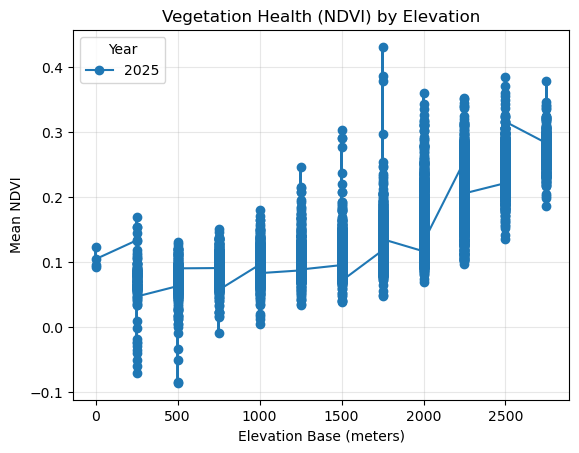

In [5]:
for yr in veg_stats_df['year'].unique():
    # Filter the data for just this year
    yr_data = veg_stats_df[veg_stats_df['year'] == yr].sort_values('height')
    
    plt.plot(
        yr_data['height'], 
        yr_data['mean'], 
        marker='o', 
        label=yr
    )

plt.title("Vegetation Health (NDVI) by Elevation")
plt.xlabel("Elevation Base (meters)")
plt.ylabel("Mean NDVI")
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
## backup hillsdahes that worked


print("8. DEM mosaicking started...")
dem_files = [fn for fn in downloaded_files if 'dem.tif' in fn.name]
dem_mosaic_dest = PATHS["earthaccess"] / "DEM_mosaic.TIF"
dem_meta = create_mosaic(dem_files, dem_mosaic_dest, dtype='float32')
dem_ds = xr.Dataset({"elevation":dem_windowed})
dem_ds = dem_ds.rio.write_crs(win_meta['crs']).rio.write_transform(win_meta['transform'])
dem_ds_clipped = dem_ds.rio.clip(border_gdf_proj.geometry, drop =True)
hillshade_orig = hillshade(dem_ds, azimuth=225, angle_altitude=45)
hillshade_26912 = hillshade_orig.rio.reproject("EPSG:26912")
hillshade_dest = PATHS["results"] / "hillshade.tif"
hillshade_26912.rio.to_raster(hillshade_dest, compress = "lzw")

# --- 7. Creating Hillshde
hillshade = hillshade(dem_ds, azimuth=335, angle_altitude=45)
#hillshade_26912 = hillshade_orig.rio.reproject("EPSG:26912")
hillshade_dest = PATHS["results"] / "Hillshade.tif"
#hillshade_26912.rio.to_raster(hillshade_dest, compress = "lzw")

In [ ]:
gamma = 0.8
for year in df["year"].unique():
    for disp_tsk in DISPLAY_TASKS:
        img = ds[INDEX_TO_BANDS[disp_tsk]].sel(year=year).to_array(dim='band')
        #vimn, vmax = img.min(), img.max()
        #vmin, vmax = img.quantile([0.02, 0.98]).compute()
        vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
        img_scaled = ((img - vmin)/(vmax-vmin)*255).clip(0, 255)
        img_scaled = (255 * (img_scaled / 255) ** gamma).astype("uint8")
        img_low_res = img_scaled.coarsen(x=10, y=10, boundary ="trim").mean().astype("uint8")
        img_dest = PATHS["results"] / f"{year}_{disp_tsk}_composite.tif"
        img_low_res.rio.to_raster(img_dest)
        print(f"Saved: {img_dest.name}")    


scale = 2
img = rioxarray.open_rasterio(PATHS["results"]/"2020_true_colour_composite.tif")
img_height_new = int(img.rio.height / scale)
img_width_new = int(img.rio.width / scale)
img_scaled = img.rio.reproject('EPSG:4326', shape=(img_height_new,img_width_new))
b = img_scaled.rio.bounds()
img_bounds_folium = [[b[1],b[0]],[b[3],b[2]]]
img_data = img_scaled.transpose('y','x','band').values
#if img_data.max() <= 1.0:
#    img_data = (img_data * 255).astype('uint8')
alpha = np.where(img_data.sum(axis=-1) > 0, 255, 0).astype('uint8')
img_data_rgba = np.dstack((img_data, alpha))

hill = rioxarray.open_rasterio(PATHS["results"]/"terrain_hillshade_high_res.tif")
hill_height_new = int(hill.rio.width / scale)
hill_width_new = int(hill.rio.width / scale)
hill_scaled = hill.rio.reproject('EPSG:4326', shape=(hill_height_new,hill_width_new))
h = hill_scaled.rio.bounds()
hill_bounds_folium = [[h[1],h[0]],[h[3],h[2]]]
hill_data_2d = hill_scaled.values.squeeze()
#beta = np.where(hill_data.sum(axis=-1) > 0, 255, 0).astype('uint8')
#hill_data_2d = np.dstack((hill_data, beta))



m = folium.Map([36.15, -112.7],tiles="USGS.USImagery")
folium.raster_layers.ImageOverlay(
    name = "True Colour Overaly",
    image = img_data_rgba,
    bounds = img_bounds_folium,
).add_to(m)
folium.raster_layers.ImageOverlay(
    name = "Hillshade Overaly",
    image = hill_data_2d,
    bounds = hill_bounds_folium,
    opacity = 0.4    
).add_to(m)

folium.LayerControl().add_to(m)
m

In [ ]:
# Create a mask for the river
river_mask = ds_clipped['ndwi'].isel(year=0) > 0.1
# Apply this to NDVI to analyze only 'Land' pixels
ndvi_land_only = ds_clipped['ndvi'].where(~river_mask)

def mask_from_raster(year, pathrow, NDI):#, river_ref_path):
    poly_list = []
    file = NDI_data/f"{year}_{pathrow}_{NDI}.tif"
    with rio.open(file) as src:
        non_binary = src.read(1)
        mask = np.where(non_binary > -0.1 , 255 ,0).astype("uint8")
        cleaned_mask = sieve(mask,50)
        out_meta = src.meta.copy()
        out_meta.update(dtype = "uint8", nodata = 0)
        mask_out = masks / f"{year}_{pathrow}_{NDI}.tif"
        
        with rio.open(mask_out, "w", **out_meta) as dst:
            dst.write(cleaned_mask,1)

    file = mask_data / f"{year}_{pathrow}_{NDI}.tif"
    with rio.open(file) as src:
        tile = src.read(1).astype("int16")
        out_meta = src.meta.copy()
        mask_shapes = features.shapes(
            tile,
            mask = tile > 0,
            transform = out_meta['transform']
        )
    # The corrected list comprehension
    polygons = [
    {'geometry':shape(s),'properties':{'id': i}}
     for i, (s,v) in enumerate(mask_shapes)
    ]
              
    gdf = gpd.GeoDataFrame.from_features(polygons, crs=out_meta['crs'])
    return gdf

    